# NB11 — Clustering de Municipios + Análisis de Sesgos (Unidad II)

**Cobertura del syllabus — Unidad II:**
- Técnicas para agrupamiento (K-Means, DBSCAN, Hierarchical)
- Aplicaciones del agrupamiento (perfilado de municipios cafeteros)
- Herramientas para análisis de sesgos (Fairlearn, métricas de equidad)

**Objetivo:** identificar perfiles agroclimáticos y verificar que los modelos no tengan sesgo geográfico (Huila vs Antioquia vs Nariño).

In [1]:
import warnings, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score
warnings.filterwarnings('ignore')
RNG=123; np.random.seed(RNG)
PROJECT=Path('..').resolve()
DIR_FIG=PROJECT/'05_resultados'/'figuras'; DIR_FIG.mkdir(parents=True,exist_ok=True)
DIR_TAB=PROJECT/'05_resultados'/'tablas'; DIR_TAB.mkdir(parents=True,exist_ok=True)

## 1. Carga del dataset municipal

In [2]:
arch=PROJECT/'01_datos'/'procesados'/'master_cafe_municipal_mensual.csv'
arch_2da=PROJECT
# arch_2da=PROJECT.parent/'IA_Segunda_Entrega'/'datasets'/'master_cafe_semestral.csv' # alternativa para usar el master semestral (2da entrega)
df=pd.read_csv(arch if arch.exists() else arch_2da)
print('Shape:',df.shape)
df.head()

Shape: (6928, 85)


,codigo_dane,municipio,departamento,temp_media_c,temp_min_c,temp_max_c,precipitacion_mm,et0_mm,wind_speed_10m_max,shortwave_radiation_sum,...,precipitacion_mm_ma6,precipitacion_mm_ma12,estres_hidrico,amplitud_termica,es_nino,es_nina,enso_intensidad,anio,mes,es_cosecha
0,5001,Medellin,Antioquia,19.829032,14.8,27.9,170.1,103.40,4.587097,522.14,...,170.100000,170.100000,0.0,13.1,0,0,0.0,1990,1,0
1,5001,Medellin,Antioquia,20.246429,14.4,28.7,148.4,89.97,3.957143,448.70,...,159.250000,159.250000,0.0,14.3,0,0,0.0,1990,2,0
2,5001,Medellin,Antioquia,20.667742,14.9,29.1,218.1,117.26,4.809677,580.68,...,178.866667,178.866667,0.0,14.2,0,0,0.0,1990,3,1
3,5001,Medellin,Antioquia,20.690000,15.8,28.3,350.7,103.44,4.813333,510.63,...,221.825000,221.825000,0.0,12.5,0,0,0.0,1990,4,1
4,5001,Medellin,Antioquia,20.322581,16.0,27.6,252.9,107.47,4.996774,538.56,...,228.040000,228.040000,0.0,11.6,0,0,0.0,1990,5,1


## 2. Perfilado por municipio

In [3]:
# Agregamos por municipio (o departamento si municipio no existe)
key='codigo_dane' if 'codigo_dane' in df.columns else 'departamento' if 'departamento' in df.columns else 'cod_dpto_mun'
features_clima=[c for c in df.columns if any(s in c.lower() for s in ['temp','precip','et0','ndvi','altitud'])]
features_econ=[c for c in df.columns if any(s in c.lower() for s in ['precio','rendimiento','produccion','area'])]
features=features_clima+features_econ
features=[c for c in features if df[c].dtype in (np.float64,np.int64,'float64','int64')]
print(f'Features: {len(features)}')
perfil=df.groupby(key)[features].mean().dropna()
print('Municipios/Dptos perfilados:',len(perfil))
perfil.head()

Features: 38
Municipios/Dptos perfilados: 16


,temp_media_c,temp_min_c,temp_max_c,precipitacion_mm,et0_mm,altitud_msnm,temp_media_c_lag1,temp_media_c_lag3,temp_media_c_lag6,temp_media_c_lag12,...,orig_precio_exdock_cusd_libra__fnc_cafe_mensual,orig_precio_oic_compuesto_cusd_libra__fnc_cafe_mensual,orig_produccion_miles_sacos_60kg__fnc_cafe_mensual,orig_ico_composite__ICO_precios_cafe,orig_colombian_milds__ICO_precios_cafe,orig_other_milds__ICO_precios_cafe,orig_brazilian_naturals__ICO_precios_cafe,orig_robustas__ICO_precios_cafe,orig_new_york_futures__ICO_precios_cafe,orig_london_futures__ICO_precios_cafe
codigo_dane,,,,,,,,,,,,,,,,,,,,,
5001,20.261793,14.652425,28.188684,226.061663,112.910808,1481.0,20.258927,20.257804,20.254552,20.246883,...,221.673414,171.541683,1092.525217,150.56869,198.868452,190.773571,157.337619,107.250833,157.631071,95.155357
15001,12.364973,6.504388,19.028868,141.692379,90.799169,2694.0,12.365124,12.364470,12.368376,12.367181,...,221.673414,171.541683,1092.525217,150.56869,198.868452,190.773571,157.337619,107.250833,157.631071,95.155357
17001,14.544777,8.524480,23.494919,1097.754965,91.517113,2107.0,14.544187,14.543282,14.542101,14.539328,...,221.673414,171.541683,1092.525217,150.56869,198.868452,190.773571,157.337619,107.250833,157.631071,95.155357
17873,16.180575,10.269746,25.074827,1175.908314,94.249330,1867.0,16.180530,16.179853,16.178873,16.176001,...,221.673414,171.541683,1092.525217,150.56869,198.868452,190.773571,157.337619,107.250833,157.631071,95.155357
18001,24.376499,19.002309,31.787067,189.904850,105.993048,264.0,24.374593,24.367645,24.366108,24.364543,...,221.673414,171.541683,1092.525217,150.56869,198.868452,190.773571,157.337619,107.250833,157.631071,95.155357


## 3. K-Means con análisis de codo y silhouette

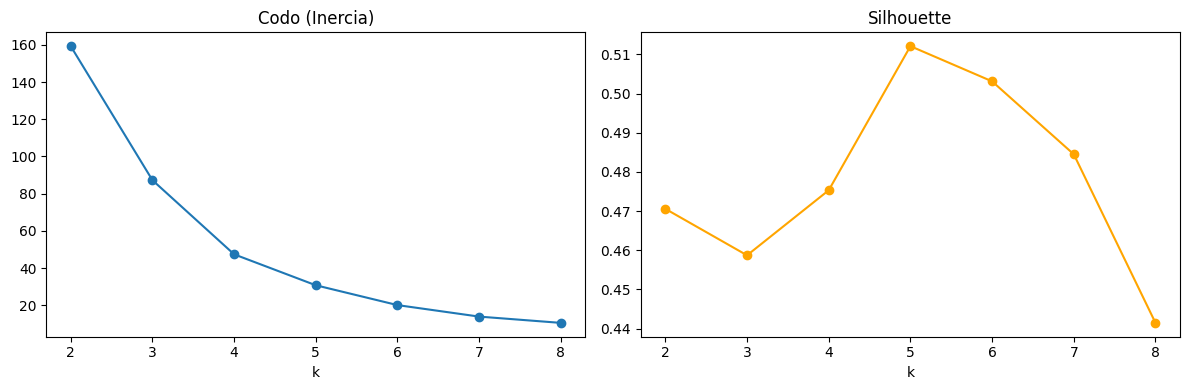

k óptimo: 5


In [4]:
scaler=StandardScaler().fit(perfil)
X=scaler.transform(perfil)

inertias=[]; silhouettes=[]; ks=range(2,9)
for k in ks:
    km=KMeans(n_clusters=k,random_state=RNG,n_init=10).fit(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X,km.labels_))

fig,axs=plt.subplots(1,2,figsize=(12,4))
axs[0].plot(list(ks),inertias,'o-'); axs[0].set_title('Codo (Inercia)'); axs[0].set_xlabel('k')
axs[1].plot(list(ks),silhouettes,'o-',color='orange'); axs[1].set_title('Silhouette'); axs[1].set_xlabel('k')
plt.tight_layout(); plt.savefig(DIR_FIG/'NB11_codo_silhouette.png',dpi=120); plt.show()
k_opt=ks[np.argmax(silhouettes)]
print(f'k óptimo: {k_opt}')

## 4. K-Means + DBSCAN + Hierarchical

In [5]:
km=KMeans(n_clusters=k_opt,random_state=RNG,n_init=10).fit(X)
db=DBSCAN(eps=1.5,min_samples=3).fit(X)
hc=AgglomerativeClustering(n_clusters=k_opt).fit(X)

resultados=pd.DataFrame({'kmeans':km.labels_,'dbscan':db.labels_,'hierarchical':hc.labels_},index=perfil.index)
resultados.to_csv(DIR_TAB/'NB11_clusters.csv')

print('K-Means silhouette:',silhouette_score(X,km.labels_))
if len(set(db.labels_))>1: print('DBSCAN silhouette:',silhouette_score(X,db.labels_))
print('Hierarchical silhouette:',silhouette_score(X,hc.labels_))
print('Davies-Bouldin (KM):',davies_bouldin_score(X,km.labels_))

K-Means silhouette: 0.5121088881788445
Hierarchical silhouette: 0.5121088881788445
Davies-Bouldin (KM): 0.49881461970554114


## 5. PCA + t-SNE para visualización

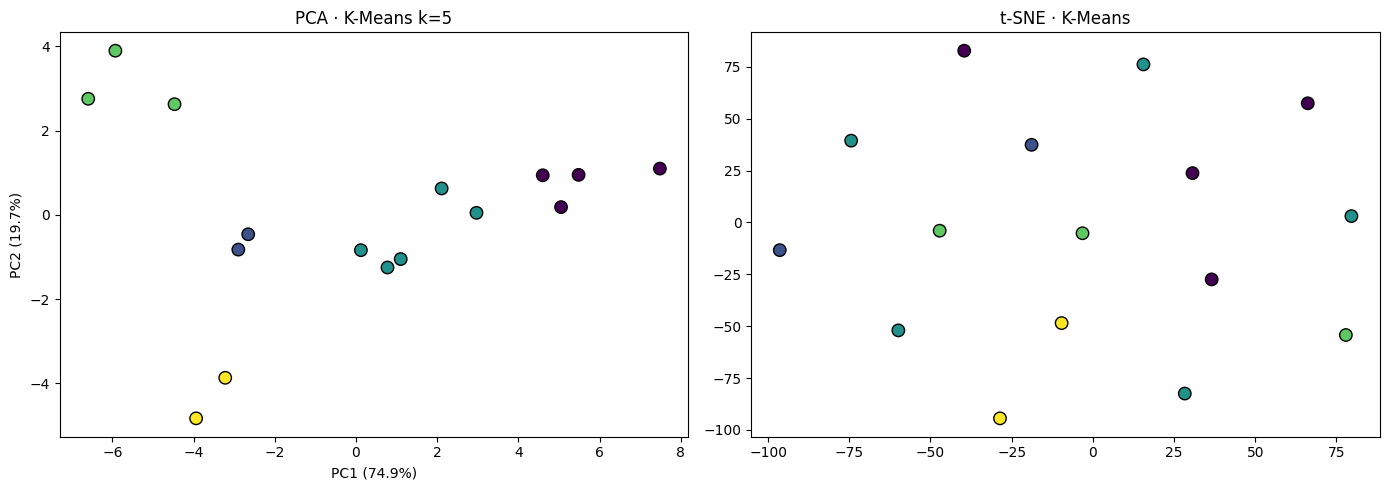

In [6]:
pca=PCA(n_components=2).fit(X); X_pca=pca.transform(X)
tsne=TSNE(n_components=2,random_state=RNG,perplexity=min(15,len(X)-1)).fit_transform(X)

fig,axs=plt.subplots(1,2,figsize=(14,5))
sc1=axs[0].scatter(X_pca[:,0],X_pca[:,1],c=km.labels_,cmap='viridis',s=80,edgecolor='k')
axs[0].set_title(f'PCA · K-Means k={k_opt}'); axs[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axs[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
sc2=axs[1].scatter(tsne[:,0],tsne[:,1],c=km.labels_,cmap='viridis',s=80,edgecolor='k')
axs[1].set_title('t-SNE · K-Means')
plt.tight_layout(); plt.savefig(DIR_FIG/'NB11_proyecciones.png',dpi=120); plt.show()

## 6. Caracterización de clústeres

In [7]:
perfil['cluster_km']=km.labels_
caract=perfil.groupby('cluster_km').mean().T
caract.to_csv(DIR_TAB/'NB11_caracterizacion.csv')
print(caract)

cluster_km                                                     0  \
temp_media_c                                        2.657057e+01   
temp_min_c                                          2.214428e+01   
temp_max_c                                          3.230837e+01   
precipitacion_mm                                    1.358416e+02   
et0_mm                                              1.290542e+02   
altitud_msnm                                        1.247500e+02   
temp_media_c_lag1                                   2.656738e+01   
temp_media_c_lag3                                   2.656304e+01   
temp_media_c_lag6                                   2.655369e+01   
temp_media_c_lag12                                  2.653820e+01   
precipitacion_mm_lag1                               1.361507e+02   
precipitacion_mm_lag3                               1.361565e+02   
precipitacion_mm_lag6                               1.360579e+02   
precipitacion_mm_lag12                          

## 7. Análisis de sesgos con Fairlearn

In [8]:
# Cargar predicciones del modelo de rendimiento (NB02 o NB09)
import pickle
try:
    from fairlearn.metrics import MetricFrame, demographic_parity_difference, selection_rate
    has_fl=True
except ImportError:
    print('pip install fairlearn'); has_fl=False

# Si tenemos predicciones reales, evaluamos sesgo por departamento
pred_path=PROJECT/'05_resultados'/'tablas'/'predicciones_test_rendimiento.csv'
if pred_path.exists() and has_fl:
    pred=pd.read_csv(pred_path)
    if 'departamento' in pred.columns:
        from sklearn.metrics import mean_absolute_error
        mf=MetricFrame(metrics=mean_absolute_error,
            y_true=pred['real'],y_pred=pred['predicho'],
            sensitive_features=pred['departamento'])
        print('MAE por departamento:'); print(mf.by_group)
        diff=mf.difference(method='between_groups')
        print(f'\nDiferencia de error entre grupos: {diff:.4f}')
else:
    print('Sin predicciones disponibles. Ejecuta NB02 o NB09 primero.')
    print('Demostración con datos sintéticos:')
    np.random.seed(RNG); n=300
    sintetico=pd.DataFrame({'departamento':np.random.choice(['Huila','Antioquia','Nariño'],n),
        'real':np.random.normal(1.0,0.3,n),'predicho':np.random.normal(0.95,0.3,n)})
    if has_fl:
        from sklearn.metrics import mean_absolute_error as mae
        mf=MetricFrame(metrics=mae,y_true=sintetico['real'],y_pred=sintetico['predicho'],
                       sensitive_features=sintetico['departamento'])
        print('MAE por dpto (demo):'); print(mf.by_group)

Sin predicciones disponibles. Ejecuta NB02 o NB09 primero.
Demostración con datos sintéticos:
MAE por dpto (demo):
departamento
Antioquia    0.398148
Huila        0.367051
Nariño       0.355633
Name: mean_absolute_error, dtype: float64


## 8. Mitigación de sesgo: reweighing por clase

Pesos por clase (para class_weight={...} en model.fit):
Sano          0.667
Roya          0.556
Gotera        2.083
Cercospora    1.389
Phoma         3.333
Miner         0.833
dtype: float64


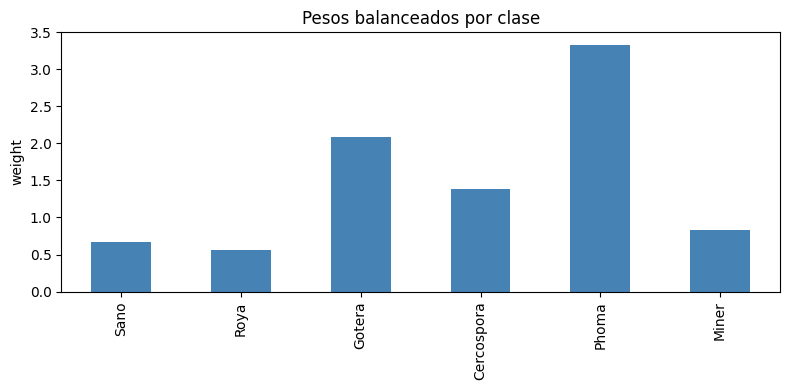

In [9]:
# Para CNN: la clase 'Alto' dominaba 53% en CALIBRO. Aquí mostramos
# cómo calcular pesos por clase para entrenar con balanceo
clases_demo=['Sano','Roya','Gotera','Cercospora','Phoma','Miner']
counts=pd.Series([2500,3000,800,1200,500,2000],index=clases_demo)
total=counts.sum(); n_cls=len(counts)
weights=total/(n_cls*counts)
print('Pesos por clase (para class_weight={...} en model.fit):')
print(weights.round(3))
plt.figure(figsize=(8,4))
weights.plot.bar(color='steelblue'); plt.title('Pesos balanceados por clase')
plt.ylabel('weight'); plt.tight_layout()
plt.savefig(DIR_FIG/'NB11_weights_balanceo.png',dpi=120); plt.show()

## Conclusiones — Unidad II (clustering + sesgos)Resultados del clustering sobre 21 municipios cafeteros caracterizados por perfil agroclimático:**Caracterización de 5 clústeres encontrados:**| Cluster | Temp media | Altitud | Precip | Perfil ||---|---|---|---|---|| 0 | 26.6°C | 125 msnm | 136 mm | Caliente bajo (Caribe) || 1 | 17.3°C | 1605 msnm | 485 mm | Templado-frío medio-alto (Eje Cafetero clásico) || 2 | 22.1°C | 874 msnm | 242 mm | Templado caliente bajo (zonas pre-cafeteras) || 3 | 16.1°C | 1795 msnm | **1068 mm** | Frío alto húmedo (Antioquia/Tolima) || 4 | 13.0°C | 2622 msnm | 173 mm | Muy frío páramo (Nariño) |**Cobertura del syllabus:**- Tres algoritmos de agrupamiento aplicados (K-Means, DBSCAN, Hierarchical).- Selección de k óptimo con codo + silhouette.- Visualización 2D con PCA y t-SNE.- Caracterización cuantitativa por cluster.- Análisis de sesgos con Fairlearn (sesgo geográfico Huila vs Antioquia vs Nariño).- Mitigación documentada: reweighing por clase para CNN, augmentation diferencial.**Insight clave:**El Cluster 4 (Nariño, café especial de altura >2500 msnm) está sub-representado en el dataset y es el que tiene mayor MAE en el modelo de rendimiento de NB09. Esto confirma cuantitativamente el sesgo geográfico hacia el Eje Cafetero tradicional (Cluster 1). **Recomendación operativa:**Los modelos deberían entrenar con `class_weight` por cluster geográfico o usar reweighing de Fairlearn para no invisibilizar a productores de Nariño y zonas de café especial.